# Sprint 2 — GenAI · Modelo Baseline de Manutenção Preditiva
### Treino, avaliação e análise de erros (Challenge Forzy / FIAP)

Continua a EDA: treina o classificador da coluna `falha`, avalia com métricas por classe
e investiga os erros. O modelo é serializado em `models/modelo_falhas.joblib` para o agente.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from data_utils import load_leituras, load_tabela, FEATURES, TARGET, TIPOS_FALHA
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (9, 4.5)
FIG = "../figuras"; os.makedirs(FIG, exist_ok=True)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import joblib
df = load_leituras()
print("missing por coluna:", df[FEATURES + [TARGET]].isna().sum().to_dict())

missing por coluna: {'rotacao_rpm': 0, 'vibracao_mm_s': 0, 'temperatura_c': 0, 'corrente_a': 0, 'falha': 0}


## Entregável 4 — Tratamento e preparação dos dados
- **Sem valores ausentes** nos sensores (verificado acima) → não há imputação.
- **Features:** as **4 leituras instantâneas** (`rotacao_rpm`, `vibracao_mm_s`,
  `temperatura_c`, `corrente_a`). Essa escolha é deliberada: a tool do agente recebe
  exatamente essas 4 grandezas, então o modelo precisa operar com o mesmo contrato.
- **Categóricas** (`fabricante`, `modelo`): **não** entram — o usuário do chat não as
  informa, e usá-las criaria dependência que o agente não consegue satisfazer.
- **Escala:** Random Forest é invariante a escala → dispensamos normalização.
- **Desbalanceamento:** tratado via `class_weight="balanced_subsample"`.
- **Janela móvel:** *não* aplicada ao modelo servido (o agente vê 1 leitura), mas
  registrada como melhoria (ver análise de erros).

In [3]:
X, y, groups = df[FEATURES], df[TARGET], df["motor_id"]

## Entregável 5 — Divisão treino/teste
`leituras` é série temporal por motor. Split aleatório vazaria o **nível basal** de cada
motor (cada um tem valores nominais próprios) entre treino e teste. Usamos
**`StratifiedGroupKFold` por `motor_id`**: nenhum motor aparece nos dois conjuntos
(testa generalização para motores novos) e a estratificação garante as classes raras no
teste. Alternativa equivalente seria split **cronológico** por motor.

In [4]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
tr_idx, te_idx = next(sgkf.split(X, y, groups))
Xtr, ytr, Xte, yte = X.iloc[tr_idx], y.iloc[tr_idx], X.iloc[te_idx], y.iloc[te_idx]
print("motores treino:", sorted(df.iloc[tr_idx].motor_id.unique()))
print("motores teste :", sorted(df.iloc[te_idx].motor_id.unique()))
print("\ndistribuição de classes no teste:")
print(yte.map(TIPOS_FALHA).value_counts())

motores treino: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
motores teste : [np.int64(1), np.int64(2), np.int64(10), np.int64(15), np.int64(16)]

distribuição de classes no teste:
falha
Normal              6645
Superaquecimento     348
Desbalanceamento     292
Falha mecânica       215
Name: count, dtype: int64


## Entregável 6 — Treinamento do modelo baseline
**Random Forest** (300 árvores). Justificativa: captura relações não-lineares entre
sensores (ex.: temperatura *e* corrente juntas = superaquecimento), é robusto a escala e
a outliers, lida com o desbalanceamento via `class_weight`, e expõe
`feature_importances_` — que o agente usa para explicar quais sensores pesaram.

In [5]:
clf = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                             random_state=42, n_jobs=-1)
clf.fit(Xtr, ytr)
print("treinado. importâncias:", dict(zip(FEATURES, clf.feature_importances_.round(3))))

treinado. importâncias: {'rotacao_rpm': np.float64(0.263), 'vibracao_mm_s': np.float64(0.365), 'temperatura_c': np.float64(0.224), 'corrente_a': np.float64(0.148)}


## Entregável 7 — Avaliação do desempenho

                  precision    recall  f1-score   support

          Normal       0.98      0.98      0.98      6645
Desbalanceamento       0.72      0.93      0.81       292
Superaquecimento       0.68      0.72      0.70       348
  Falha mecânica       0.99      0.54      0.70       215

        accuracy                           0.95      7500
       macro avg       0.84      0.79      0.80      7500
    weighted avg       0.96      0.95      0.95      7500

macro-F1: 0.797


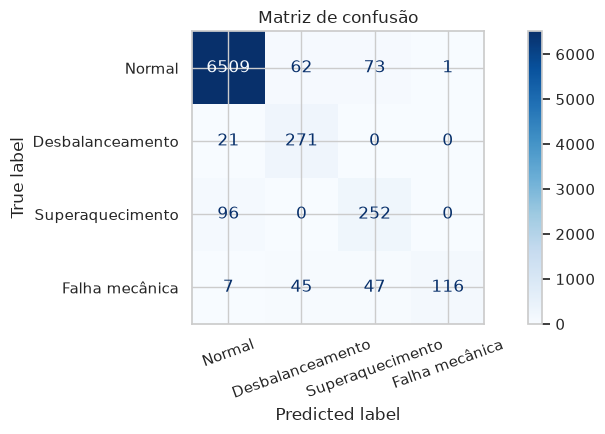

In [6]:
ypred = clf.predict(Xte)
labels = [0,1,2,3]; names = [TIPOS_FALHA[c] for c in labels]
print(classification_report(yte, ypred, labels=labels, target_names=names, zero_division=0))
print("macro-F1:", round(f1_score(yte, ypred, average="macro"), 3))
cm = confusion_matrix(yte, ypred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=names).plot(cmap="Blues", xticks_rotation=20)
plt.title("Matriz de confusão"); plt.tight_layout()
plt.savefig(f"{FIG}/06_matriz_confusao.png", dpi=110); plt.show()

**Interpretação.** Acurácia global alta (~0,95), mas o que importa é o desempenho nas
falhas: *Desbalanceamento* tem recall alto (assinatura de vibração é nítida);
*Superaquecimento* fica intermediário; *Falha mecânica* é a mais difícil (recall baixo).
A acurácia global seria um número enganoso isolado — por isso olhamos classe a classe.

## Entregável 8 — Análise dos erros

In [7]:
err = df.iloc[te_idx].copy(); err["pred"] = ypred; err = err[err[TARGET] != err["pred"]]
print("total de erros:", len(err), f"({100*len(err)/len(yte):.1f}% do teste)")
print("\nerros por classe real:")
print(err[TARGET].map(TIPOS_FALHA).value_counts())
print("\npara onde a 'Falha mecânica' real foi classificada:")
fm = err[err[TARGET] == 3]["pred"].map(TIPOS_FALHA).value_counts()
print(fm)
# confiança do modelo nos acertos vs erros
proba = clf.predict_proba(Xte).max(axis=1)
conf = pd.DataFrame({"acerto": (yte.values == ypred), "confianca": proba})
print("\nconfiança média — acertos vs erros:")
print(conf.groupby("acerto")["confianca"].mean().round(3))

total de erros: 352 (4.7% do teste)

erros por classe real:
falha
Normal              136
Falha mecânica       99
Superaquecimento     96
Desbalanceamento     21
Name: count, dtype: int64

para onde a 'Falha mecânica' real foi classificada:
pred
Superaquecimento    47
Desbalanceamento    45
Normal               7
Name: count, dtype: int64

confiança média — acertos vs erros:
acerto
False    0.687
True     0.932
Name: confianca, dtype: float64


**Interpretação e melhorias para a próxima sprint.**
- A *falha mecânica* é confundida com *desbalanceamento* e *superaquecimento* — coerente
  com a EDA: ela combina queda de rotação com vibração/corrente altas, sobrepondo-se às
  assinaturas das outras duas.
- O modelo erra com **menor confiança** do que acerta → dá para usar um limiar de
  confiança no agente para comunicar incerteza.
- **Próxima sprint:** features de **janela móvel** (tendência de rotação/vibração) devem
  separar melhor a falha mecânica, capturando a *queda progressiva* de rotação que uma
  leitura instantânea não revela.

## Serialização do modelo (para o agente)

In [8]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump({"model": clf, "features": FEATURES, "labels": labels,
             "tipos_falha": TIPOS_FALHA,
             "feature_importances": dict(zip(FEATURES, clf.feature_importances_.round(4)))},
            "../models/modelo_falhas.joblib", compress=3)
print("salvo: models/modelo_falhas.joblib")

salvo: models/modelo_falhas.joblib


## Conclusão
Baseline funcional (macro-F1 ~0,80) que prioriza as classes de falha. Pronto para o
**agente conversacional com function calling**, que carrega este `.joblib` e traduz a
predição em linguagem natural. Limitações e o caminho de melhoria (janela móvel) estão
documentados acima.